In [2]:
from itertools import combinations

рёбра = [
    (1, 2), (1, 3),
    (2, 4), (2, 5),
    (3, 4), (3, 6),
    (4, 5), (4, 7),
    (5, 7), (6, 7)
]

узлы = [1, 2, 3, 4, 5, 6, 7]


def является_независимым(подмножество, рёбра):
    for (у, в) in рёбра:
        if у in подмножество and в in подмножество:
            return False
    return True


def найти_макс_независимое_множество(узлы, рёбра):
    for размер in range(len(узлы), 0, -1):
        for подмножество in combinations(узлы, размер):
            if является_независимым(подмножество, рёбра):
                print(f"✓ Найдено независимое множество размера {размер}: {подмножество}")
                return list(подмножество)
    return []


результат = найти_макс_независимое_множество(узлы, рёбра)
print(f"\nОтвет: {результат}  (размер {len(результат)})")

✓ Найдено независимое множество размера 3: (1, 4, 6)

Ответ: [1, 4, 6]  (размер 3)


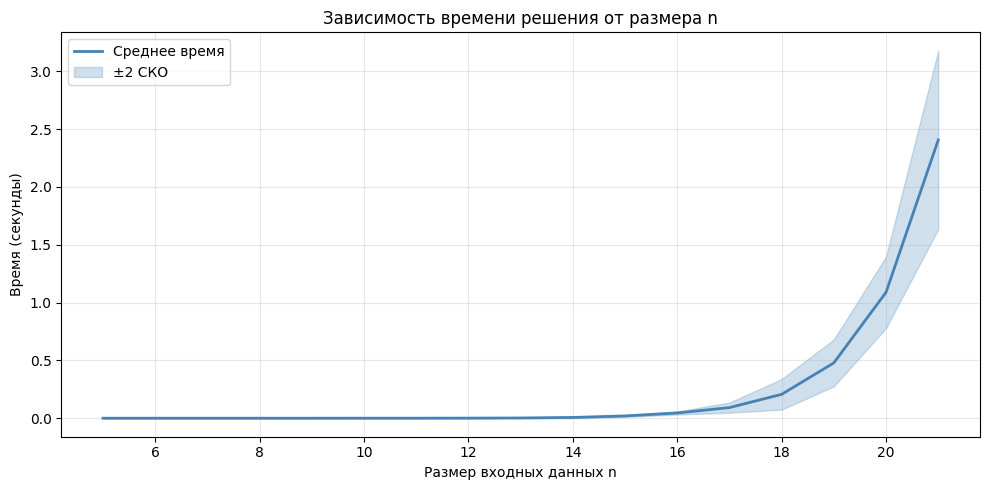

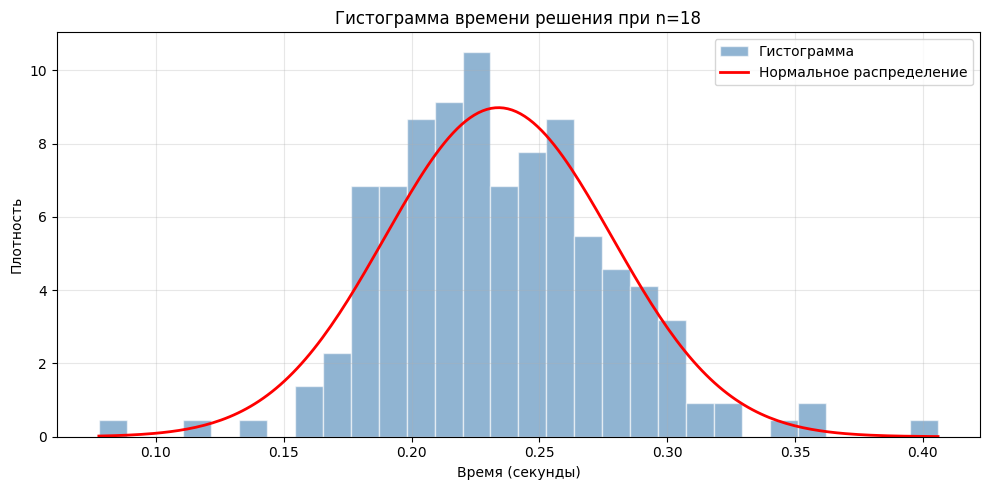

Распределение не нормальное (p = 0.0157)
Среднее время при n=18: 0.2340с
Сложность алгоритма O(2^n) — время не является хорошим для больших n


In [1]:
import time
import random
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from scipy import stats


def является_независимым(подмножество, рёбра):
    for (у, в) in рёбра:
        if у in подмножество and в in подмножество:
            return False
    return True


def найти_макс_независимое_множество(узлы, рёбра):
    for размер in range(len(узлы), 0, -1):
        for подмножество in combinations(узлы, размер):
            if является_независимым(подмножество, рёбра):
                return list(подмножество)
    return []


def случайный_граф(n, вероятность_ребра=0.4):
    узлы = list(range(1, n + 1))
    рёбра = []
    for i in узлы:
        for j in узлы:
            if j > i and random.random() < вероятность_ребра:
                рёбра.append((i, j))
    return узлы, рёбра


# График 1 — время от размера n

размеры = list(range(5, 22))
повторений = 15
средние = []
ско = []

for n in размеры:
    времена = []
    for _ in range(повторений):
        узлы, рёбра = случайный_граф(n)
        начало = time.time()
        найти_макс_независимое_множество(узлы, рёбра)
        конец = time.time()
        времена.append(конец - начало)
    средние.append(np.mean(времена))
    ско.append(np.std(времена))

средние = np.array(средние)
ско = np.array(ско)

plt.figure(figsize=(10, 5))
plt.plot(размеры, средние, color='steelblue', linewidth=2, label='Среднее время')
plt.fill_between(размеры,
                 средние - 2 * ско,
                 средние + 2 * ско,
                 alpha=0.25, color='steelblue', label='±2 СКО')
plt.xlabel('Размер входных данных n')
plt.ylabel('Время (секунды)')
plt.title('Зависимость времени решения от размера n')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('график_времени.png', dpi=150)
plt.show()


# График 2 — гистограмма с кривой для n=18

выбранное_n = 18
времена_для_гистограммы = []

for _ in range(200):
    узлы, рёбра = случайный_граф(выбранное_n)
    начало = time.time()
    найти_макс_независимое_множество(узлы, рёбра)
    конец = time.time()
    времена_для_гистограммы.append(конец - начало)

среднее = np.mean(времена_для_гистограммы)
отклонение = np.std(времена_для_гистограммы)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(времена_для_гистограммы, bins=30,
        color='steelblue', edgecolor='white',
        alpha=0.6, density=True, label='Гистограмма')

x = np.linspace(min(времена_для_гистограммы),
                max(времена_для_гистограммы), 200)
ax.plot(x, stats.norm.pdf(x, среднее, отклонение),
        color='red', linewidth=2, label='Нормальное распределение')

ax.set_xlabel('Время (секунды)')
ax.set_ylabel('Плотность')
ax.set_title(f'Гистограмма времени решения при n={выбранное_n}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('гистограмма.png', dpi=150)
plt.show()


# Проверка 

статистика, p_значение = stats.shapiro(времена_для_гистограммы)

if p_значение > 0.05:
    print(f"Распределение нормальное (p = {p_значение:.4f})")
else:
    print(f"Распределение не нормальное (p = {p_значение:.4f})")

print(f"Среднее время при n={выбранное_n}: {среднее:.4f}с")
print(f"Сложность алгоритма O(2^n) — время не является хорошим для больших n")